In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.utils import make_nice_plots, get_pdfs

make_nice_plots()


In [2]:
label = '_zleq3_final_kmax5_gwtc5_luminformed_smoothcorr'  #'_zleq3_final_kmax5_gwtc5_luminformed'  # '_zleq3_final_kmax5_gwtc5_neglecterror'  # _MF
zmodel = 'madau'

json_withcat = f'/home/lucas/Documents/PhD/generated_data/jsons/real_output_{zmodel}{label}.json'
json_emptycat = f'/home/lucas/Documents/PhD/generated_data/jsons/real_output_nocat_{zmodel}{label}.json'


44.5_kulkarni
256
alpha: 0.2504123972451084 0.41078336883249716
45.5_kulkarni
256
alpha: 0.14629632091393052 0.41078336883249716
46.5_kulkarni
256
alpha: 0.03168441448638874 0.41078336883249716
44.5_kulkarni
256
alpha: 0.2504453481898237 0.41078336883249716
45.5_kulkarni
256
alpha: 0.1463228591928513 0.41078336883249716
46.5_kulkarni
256
alpha: 0.03146192870235628 0.41078336883249716


/tmp/ipykernel_2594667/3493399744.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', 0.5, 1, 1.5, 2, 2.5, 3])


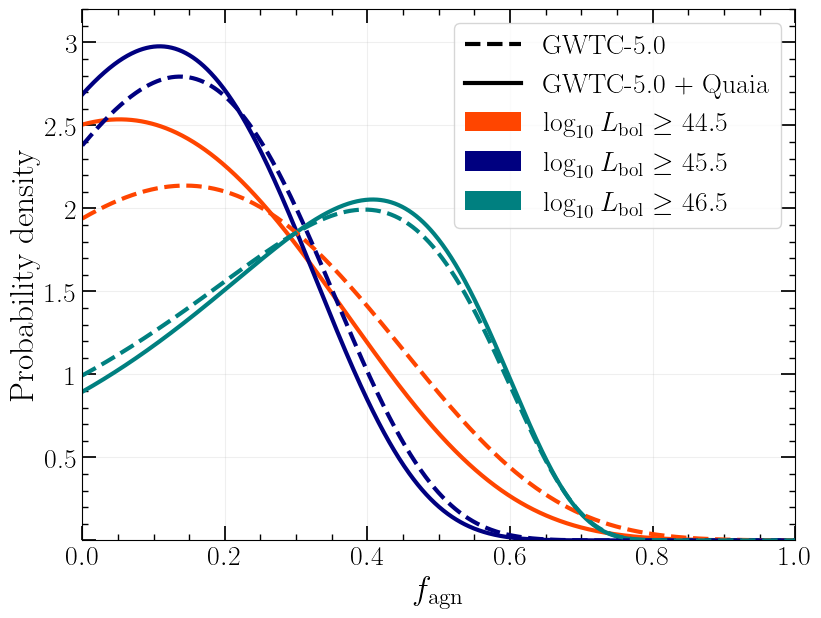

In [3]:
fig, ax = plt.subplots(figsize=(4 * 2.3, 3 * 2.3))

for k, json_path in enumerate([json_withcat, json_emptycat]):
    if k == 0:  # With catalogue
        linestyle = 'solid'
    else:
        linestyle = 'dashed'

    with open(json_path, "r") as f:
        data = json.load(f)

    for i, thresh in enumerate(['44.5_kulkarni', '45.5_kulkarni', '46.5_kulkarni']):
        print(thresh)

        gw_evidence_dict = data[str(thresh)]

        log_llh = 0
        Ngw = 0
        for gwkey in gw_evidence_dict.keys():
            S_agn_incat = gw_evidence_dict[gwkey]['S_agn_incat']
            S_agn_outofcat = gw_evidence_dict[gwkey]['S_agn_outcat']
            S_alt = gw_evidence_dict[gwkey]['S_alt']

            # print(f'GW: {gwkey}, Sagn incat: {S_agn_incat}, Sagn outcat: {S_agn_outofcat}, Salt: {S_alt}')

            log_llh += np.log(LOG_LLH_X_AX * (S_agn_incat + S_agn_outofcat - S_alt) + S_alt)
            Ngw += 1
        print(Ngw)

        # Correct for GW selection effects
        alpha_agn = gw_evidence_dict[gwkey]['alpha_agn']  # Same for all events, so just pick most recent one
        alpha_alt = gw_evidence_dict[gwkey]['alpha_alt']  # Same for all events
        print('alpha:', alpha_agn, alpha_alt)

        log_llh -= Ngw * np.log(LOG_LLH_X_AX * alpha_agn + (1 - LOG_LLH_X_AX) * alpha_alt)
        
        pdfs = get_pdfs(log_llh, LOG_LLH_X_AX)
        ax.plot(LOG_LLH_X_AX, pdfs, color=COLORS[i], linewidth=3, linestyle=linestyle)

ax.grid(alpha=0.2)
handles, labels = ax.get_legend_handles_labels()
custom_handles = [
    Line2D([], [], color='black', linestyle='dashed', linewidth=3, label='GWTC-5.0'),
    Line2D([], [], color='black', linestyle='solid', linewidth=3, label='GWTC-5.0 + Quaia'),
    Patch(facecolor=COLORS[0], edgecolor='none',
        label=r'$\log_{10} L_{\rm bol} \geq 44.5$'),

    Patch(facecolor=COLORS[1], edgecolor='none',
        label=r'$\log_{10} L_{\rm bol} \geq 45.5$'),

    Patch(facecolor=COLORS[2], edgecolor='none',
        label=r'$\log_{10} L_{\rm bol} \geq 46.5$'),
]
handles = custom_handles + handles
ax.legend(handles=handles)
ax.set_xlabel(r'$f_{\rm agn}$')
ax.set_ylabel('Probability density')
ax.set_xlim(0, 1)
ax.set_ylim(0, 3.2)
ax.set_yticklabels(['', 0.5, 1, 1.5, 2, 2.5, 3])
# plt.savefig(f'{PLOT_DIR}/fiducial_posteriors.pdf', bbox_inches='tight')
plt.show()


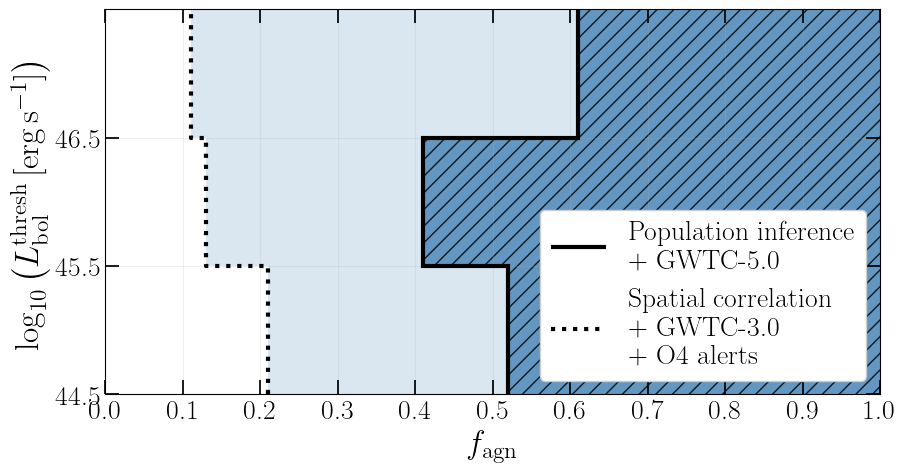

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

lumthreshes = [45, 46, 47]
# values = [1 - 0.45, 1 - 0.36, 1 - 0.60]  # 90%
# ax.barh(47, 0.04, height=1.0, alpha=0.8, color='steelblue', linewidth=3, hatch='//',)
values = [1 - 0.52, 1 - 0.41, 1 - 0.61]  # 95%
right_edge = 1
bars = ax.barh(lumthreshes, values, left=[1 - v for v in values], height=1.0, alpha=0.8, color='steelblue', linewidth=3, hatch='//',)

# Get the left edge of each bar
x_left = [bar.get_x() for bar in bars]
# Get the y boundaries
y_bottom = bars[0].get_y()
y_edges = [bar.get_y() + bar.get_height() for bar in bars]
# Build ONE continuous path along the left edges
x_line = [x_left[0]]
y_line = [y_bottom]
for i in range(len(bars)):
    # Go vertically up the left edge
    x_line.append(x_left[i])
    y_line.append(y_edges[i])
    # Connect horizontally to the next bar's left edge
    if i < len(bars) - 1:
        x_line.append(x_left[i + 1])
        y_line.append(y_edges[i])
ax.plot(
    x_line,
    y_line,
    color='black',
    linewidth=3,
    solid_capstyle='butt',
    solid_joinstyle='miter',
    label='Population inference \n+ GWTC-5.0'
)

lumthreshes = [45, 46, 47]
# values = [1 - 0.16, 1 - 0.10, 1 - 0.09]  # 90%
values = [1 - 0.21, 1 - 0.13, 1 - 0.11]  # 95%
right_edge = 1
bars = ax.barh(lumthreshes, values, left=[1 - v for v in values], height=1.0, color='steelblue', alpha=0.2, linewidth=3)

# Get the left edge of each bar
x_left = [bar.get_x() for bar in bars]
# Get the y boundaries
y_bottom = bars[0].get_y()
y_edges = [bar.get_y() + bar.get_height() for bar in bars]
# Build one continuous path along the left edges
x_line = [x_left[0]]
y_line = [y_bottom]
for i in range(len(bars)):
    # Go vertically up the left edge
    x_line.append(x_left[i])
    y_line.append(y_edges[i])
    # Connect horizontally to the next bar's left edge
    if i < len(bars) - 1:
        x_line.append(x_left[i + 1])
        y_line.append(y_edges[i])
ax.plot(
    x_line,
    y_line,
    color='black',
    linewidth=3,
    solid_capstyle='butt',
    solid_joinstyle='miter',
    linestyle='dotted',
    label='Spatial correlation \n+ GWTC-3.0 \n+ O4 alerts'
)

ax.set_xlabel(r'$f_{\rm agn}$')
ax.set_ylabel(r'$\log_{10} \left( L_{\rm bol}^{\rm thresh} \, [\mathrm{erg \, s^{-1}}] \right)$')
ax.set_yticks([44.5, 45.5, 46.5])
ax.set_yticklabels([44.5, 45.5, 46.5])
ax.set_xticks(np.around(np.arange(0, 1.1, 0.1), 1))
ax.set_xticklabels(np.around(np.arange(0, 1.1, 0.1), 1))
ax.set_ylim(44.5, 47.5)
ax.set_xlim(0, 1)
ax.minorticks_off()
ax.grid(alpha=0.2)
ax.legend(framealpha=1, loc='lower right')
plt.savefig(f'{PLOT_DIR}/constraints_onecol.pdf', bbox_inches='tight')
plt.show()
